# Dự Báo Nồng Độ PM2.5 Tại Trạm Aotizhongxin

Notebook này triển khai các bước trong file `ke_hoach_du_an.md`, bao gồm làm sạch dữ liệu, trực quan hóa và xây dựng mô hình hồi quy để dự báo nồng độ bụi mịn PM2.5.

## 1. Import Thư Viện

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')



## 2. Đọc và Kiểm Tra Dữ Liệu

In [34]:
# Đường dẫn tương đối từ thư mục notebooks tới thư mục data
data_path = '../data/Aotizhongxin_Raw.csv'
df = pd.read_csv(data_path)

print("Kích thước bộ dữ liệu:", df.shape)
df.head()

Kích thước bộ dữ liệu: (35064, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


## 3. Làm Sạch và Tiền Xử Lý Dữ Liệu

In [35]:
# Tạo cột datetime từ year, month, day, hour
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
# Đặt datetime làm index cho chuỗi thời gian
df.set_index('datetime', inplace=True)

# Xóa cột 'No' vì không mang ý nghĩa dự báo
if 'No' in df.columns:
    df.drop('No', axis=1, inplace=True)

df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [36]:
# Kiểm tra số lượng giá trị thiếu (Missing values)
print("Số lượng missing values ban đầu:\n", df.isnull().sum())

Số lượng missing values ban đầu:
 year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64


In [37]:
# Xử lý missing values
# 1. Đối với biến phân loại 'wd' (hướng gió), điền bằng giá trị xuất hiện nhiều nhất (mode)
df['wd'].fillna(df['wd'].mode()[0], inplace=True)

# 2. Đối với các biến số học, điền bằng phương pháp nội suy tuyến tính (interpolate) theo chuỗi thời gian
df.interpolate(method='time', inplace=True)

# 3. Điền các giá trị vẫn còn thiếu ở đầu/cuối bằng phương pháp bfill/ffill
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)

print("\nSố lượng missing values sau xử lý:\n", df.isnull().sum())


Số lượng missing values sau xử lý:
 year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64


In [38]:
# Mã hóa biến 'wd' (hướng gió) sang dạng số
le = LabelEncoder()
df['wd'] = le.fit_transform(df['wd'])

# Xóa cột 'station' vì toàn bộ tập này ở trạm Aotizhongxin
if 'station' in df.columns:
    df.drop('station', axis=1, inplace=True)

df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
datetime,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,6,4.4
2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,3,4.7
2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,6,5.6
2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,7,3.1
2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,3,2.0


## 4. Phân Tích Thống Kê Mô Tả

In [18]:
# Tính toán thủ công các đại lượng thống kê
stats_df = pd.DataFrame(index=['mean', 'median', 'min', 'max', 'std'])
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        stats_df.loc['mean', col] = df[col].mean()
        stats_df.loc['median', col] = df[col].median()
        stats_df.loc['min', col] = df[col].min()
        stats_df.loc['max', col] = df[col].max()
        stats_df.loc['std', col] = df[col].std()
stats_df

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
mean,2014.662560,6.522930,15.729637,11.500000,82.540623,110.210033,17.459251,59.074106,1264.692405,55.328626,13.581414,1011.851650,3.120296,0.067383,6.535735,1.708577
median,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,5.000000,1.400000
min,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000,0.000000
max,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,15.000000,11.200000
std,1.177213,3.448752,8.800218,6.922285,81.956401,95.262531,22.702284,37.000918,1239.411826,57.327470,11.400426,10.404517,13.690314,0.909798,4.679669,1.204180


## 5. Phát Hiện Ngoại Lai (Outliers)

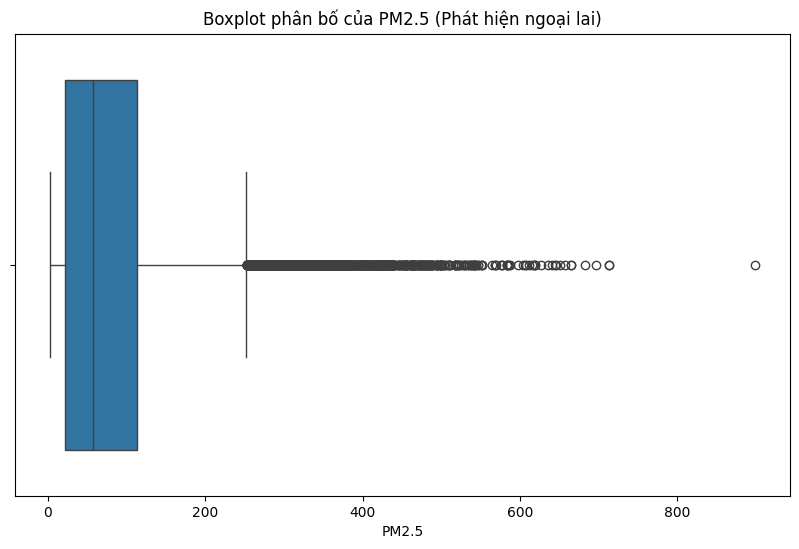

Giá trị Q1: 22.00, Q3: 114.00, IQR: 92.00
Ngưỡng trên (Upper bound): 252.00
Số lượng bản ghi vượt ngưỡng: 1653


In [49]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['PM2.5'])
plt.title('Boxplot phân bố của PM2.5 (Phát hiện ngoại lai)')
plt.xlabel('PM2.5')
plt.show()

# Tính IQR
Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Giá trị Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Ngưỡng trên (Upper bound): {upper_bound:.2f}")
print(f"Số lượng bản ghi vượt ngưỡng: {len(df[df['PM2.5'] > upper_bound])}")
# Lưu ý: Trong ô nhiễm không khí, PM2.5 có thể tăng đột biến thực sự chứ không phải do lỗi.
# Do đó, ta tạm giữ lại các giá trị ngoại lai này để mô hình học được.

## 6. Trực Quan Hóa Dữ Liệu

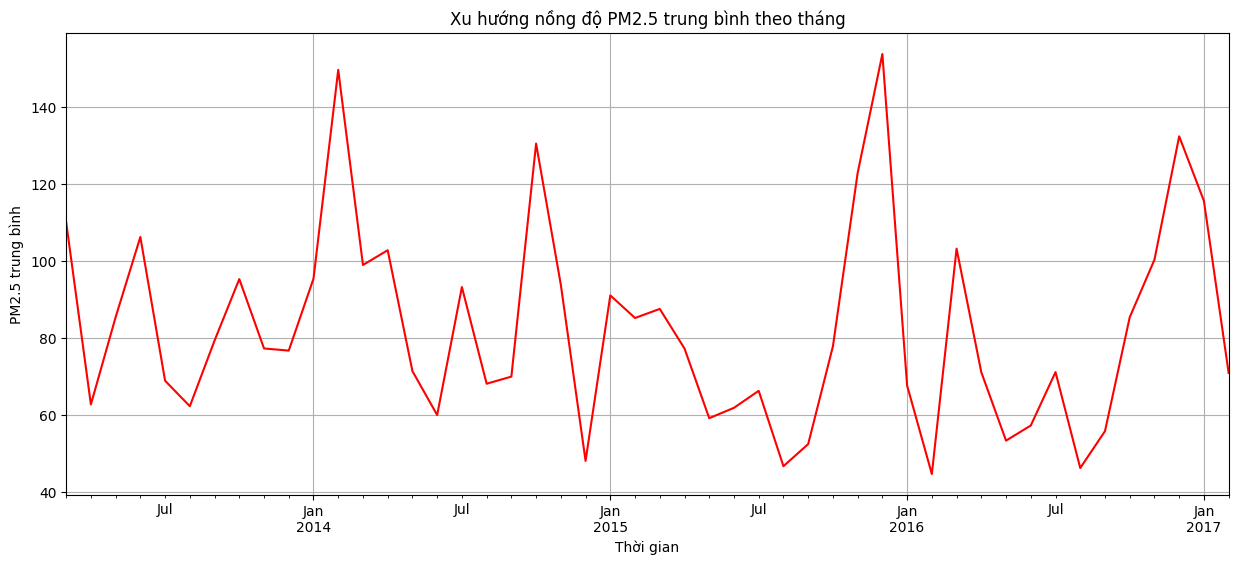

In [41]:
# 1. Line Chart: Xu hướng trung bình PM2.5 theo tháng
plt.figure(figsize=(15, 6))
df['PM2.5'].resample('M').mean().plot(color='red')
plt.title('Xu hướng nồng độ PM2.5 trung bình theo tháng')
plt.ylabel('PM2.5 trung bình')
plt.xlabel('Thời gian')
plt.grid(True)
plt.show()

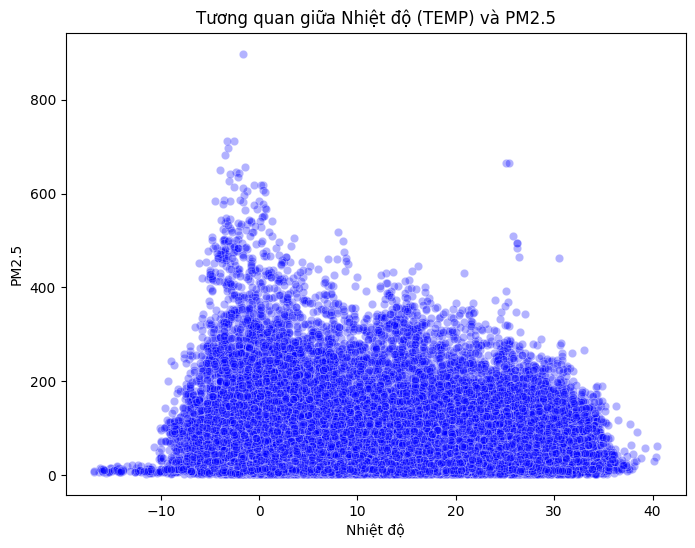

In [42]:
# 2. Scatter Plot: Tương quan giữa Nhiệt độ và PM2.5
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TEMP', y='PM2.5', data=df, alpha=0.3, color='blue')
plt.title('Tương quan giữa Nhiệt độ (TEMP) và PM2.5')
plt.xlabel('Nhiệt độ')
plt.ylabel('PM2.5')
plt.show()

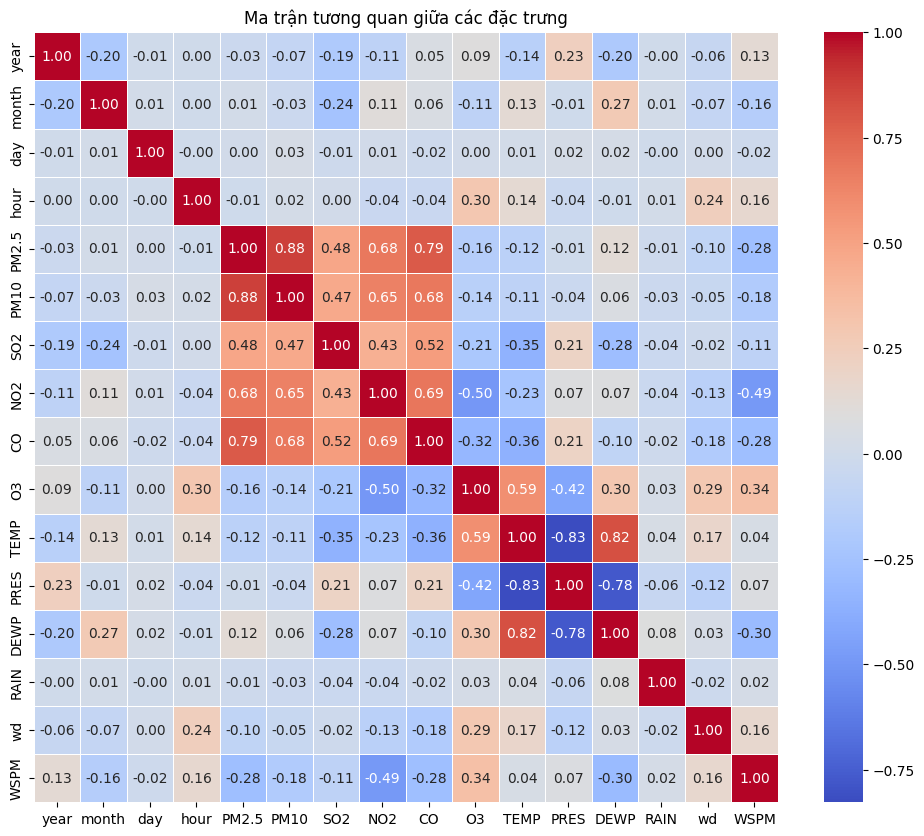

In [43]:
# 3. Correlation Heatmap: Ma trận tương quan giữa các biến
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng')
plt.show()

## 7. Tiền Xử Lý Dữ Liệu Cho Các Mô Hình
- Ta sẽ tạo ra 2 tập dữ liệu: Một tập giữ nguyên ngoại lai (cho Random Forest), và một tập đã loại bỏ ngoại lai (cho Linear Regression).

In [44]:
# Định nghĩa Đặc trưng (X) và Biến mục tiêu (y)
X = df.drop(columns=['PM2.5', 'year', 'month', 'day', 'hour'], errors='ignore')
y = df['PM2.5']

# 1. Dữ liệu gốc (Có chứa ngoại lai)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 2. Dữ liệu đã loại bỏ ngoại lai (Dựa vào ngưỡng upper_bound = 252.0 đã tính ở phần 5)
upper_bound = 252.0
df_no_outliers = df[df['PM2.5'] <= upper_bound]
X_no = df_no_outliers.drop(columns=['PM2.5', 'year', 'month', 'day', 'hour'], errors='ignore')
y_no = df_no_outliers['PM2.5']

train_size_no = int(len(X_no) * 0.8)
X_train_no, X_test_no = X_no.iloc[:train_size_no], X_no.iloc[train_size_no:]
y_train_no, y_test_no = y_no.iloc[:train_size_no], y_no.iloc[train_size_no:]

# Tiêu chuẩn hóa dữ liệu cho Linear Regression (dùng tập không ngoại lai)
scaler = StandardScaler()
X_train_no_scaled = scaler.fit_transform(X_train_no)
X_test_no_scaled = scaler.transform(X_test_no)

## 8. Mô Hình Linear Regression
**Lý do sử dụng tập dữ liệu đã xóa ngoại lai:**

Mô hình Hồi quy tuyến tính (Linear Regression) rất nhạy cảm với các điểm dữ liệu ngoại lai. Một vài giá trị PM2.5 tăng vọt bất thường có thể làm lệch hoàn toàn đường hồi quy, dẫn đến sai số lớn trên diện rộng. Do đó, với Linear Regression, ta **bắt buộc phải loại bỏ ngoại lai** để đường hồi quy mô tả đúng xu hướng trung bình của phần lớn dữ liệu.

In [45]:
# Huấn luyện mô hình Linear Regression với tập dữ liệu KHÔNG CÓ NGOẠI LAI
lr_model = LinearRegression()
lr_model.fit(X_train_no_scaled, y_train_no)
y_pred_lr = lr_model.predict(X_test_no_scaled)

# Hàm đánh giá dùng chung
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Đánh giá mô hình {model_name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}\n")

evaluate_model(y_test_no, y_pred_lr, "Linear Regression (Không ngoại lai)")

--- Đánh giá mô hình Linear Regression (Không ngoại lai) ---
MAE  : 16.3358
MSE  : 524.0252
RMSE : 22.8916
R2   : 0.8454



**Kết luận về Linear Regression:**
- Mô hình hồi quy tuyến tính sau khi loại bỏ ngoại lai có thể phác họa được phần nào xu hướng trung bình của chất lượng không khí trong những ngày bình thường.
- Tuy nhiên, nhược điểm chí mạng trong thực tế là nó **không thể cảnh báo được những ngày ô nhiễm nghiêm trọng** (bão bụi, khói mù) vì ta đã phải xóa các ngày đó khỏi tập huấn luyện. Sự phụ thuộc tuyến tính yếu giữa chất ô nhiễm và khí tượng cũng khiến chỉ số $R^2$ chưa đạt mức tối ưu.

## 9. Mô Hình Random Forest
**Lý do sử dụng tập dữ liệu giữ nguyên ngoại lai:**

Đối với dữ liệu chất lượng không khí, các điểm ngoại lai (PM2.5 cực cao) là hiện tượng vật lý có thật (đợt ô nhiễm nặng) và đây chính là những ngày cần dự báo nhất để cảnh báo sức khỏe. Mô hình Random Forest (dựa trên cây quyết định) **miễn nhiễm và hoạt động rất tốt với các giá trị ngoại lai**. Do đó, ta sẽ **giữ nguyên toàn bộ ngoại lai** để huấn luyện nhằm giúp mô hình học được cách đối phó với các tình huống ô nhiễm khắc nghiệt này.

In [47]:
# Huấn luyện mô hình Random Forest với tập dữ liệu CÓ CHỨA NGOẠI LAI
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train) # Không cần standard scaler
y_pred_rf = rf_model.predict(X_test)

evaluate_model(y_test, y_pred_rf, "Random Forest (Giữ nguyên ngoại lai)")

--- Đánh giá mô hình Random Forest (Giữ nguyên ngoại lai) ---
MAE  : 13.4999
MSE  : 476.9945
RMSE : 21.8402
R2   : 0.9318



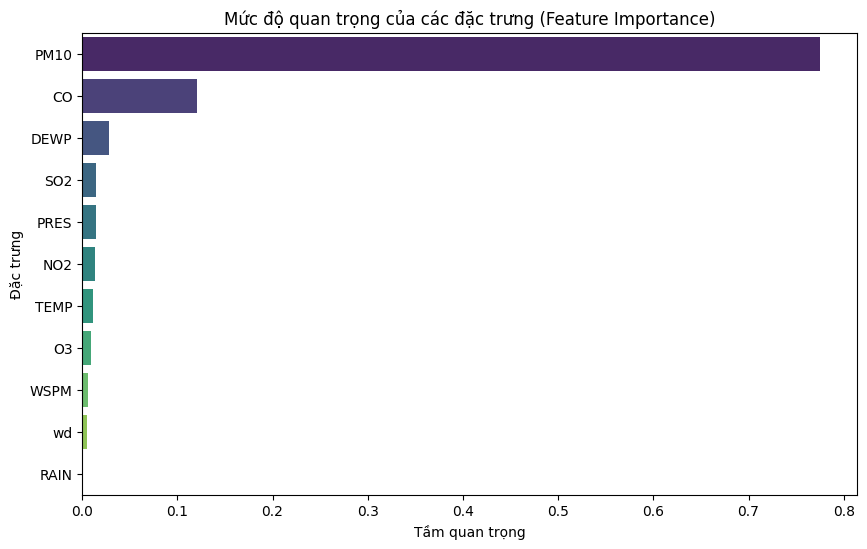

In [48]:
# Trực quan hóa Feature Importance (Mức độ quan trọng của đặc trưng) từ Random Forest
feature_importances = rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Mức độ quan trọng của các đặc trưng (Feature Importance)')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.show()

**Kết luận về Random Forest:**
- Mặc dù phải đối mặt với các giá trị nhiễu và ngoại lai cực đoan (PM2.5 tăng đột biến), Random Forest vẫn cho kết quả (R2, RMSE) rất khả quan nhờ khả năng nắm bắt quan hệ phi tuyến tính tốt và khả năng tạo nhánh rẽ riêng cho các sự kiện ô nhiễm bất thường.
- Từ đồ thị Feature Importance, có thể thấy các khí thải như PM10, CO, hoặc yếu tố thời tiết (như Điểm sương DEWP, Nhiệt độ) có đóng góp lớn nhất vào nồng độ PM2.5.